In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")
%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/apple-sales-dataset-2024/apple_sales_2024.csv


![](https://static01.nyt.com/images/2021/04/27/business/26Techfix-illo/26Techfix-illo-articleLarge.gif?quality=75&auto=webp&disable=upscale)

In [2]:
data = pd.read_csv('/kaggle/input/apple-sales-dataset-2024/apple_sales_2024.csv')
data.head()

,State,Region,iPhone Sales (in million units),iPad Sales (in million units),Mac Sales (in million units),Wearables (in million units),Services Revenue (in billion $)
0,Chongqing,Greater China,7.46,6.75,1.19,5.88,15.88
1,Germany,Europe,8.63,14.06,7.03,7.42,10.12
2,UK,Europe,5.61,14.09,8.78,8.19,19.85
3,Shanghai,Greater China,7.82,7.97,9.78,2.28,6.16
4,Thailand,Rest of Asia,16.70,8.13,6.46,3.48,13.29


In [3]:
data.isna().sum()

State                              0
Region                             0
iPhone Sales (in million units)    0
iPad Sales (in million units)      0
Mac Sales (in million units)       0
Wearables (in million units)       0
Services Revenue (in billion $)    0
dtype: int64

In [4]:
data.rename(columns={'iPhone Sales (in million units)':'iPhone_Sales','iPad Sales (in million units)':'iPad_Sales',
                     'Mac Sales (in million units)':'Mac_Sales','Wearables (in million units)':'Wearables',
                    'Services Revenue (in billion $)':'Services_Revenue'},inplace=True)

In [5]:
data.nunique()

State                25
Region                5
iPhone_Sales        824
iPad_Sales          692
Mac_Sales           595
Wearables           639
Services_Revenue    741
dtype: int64

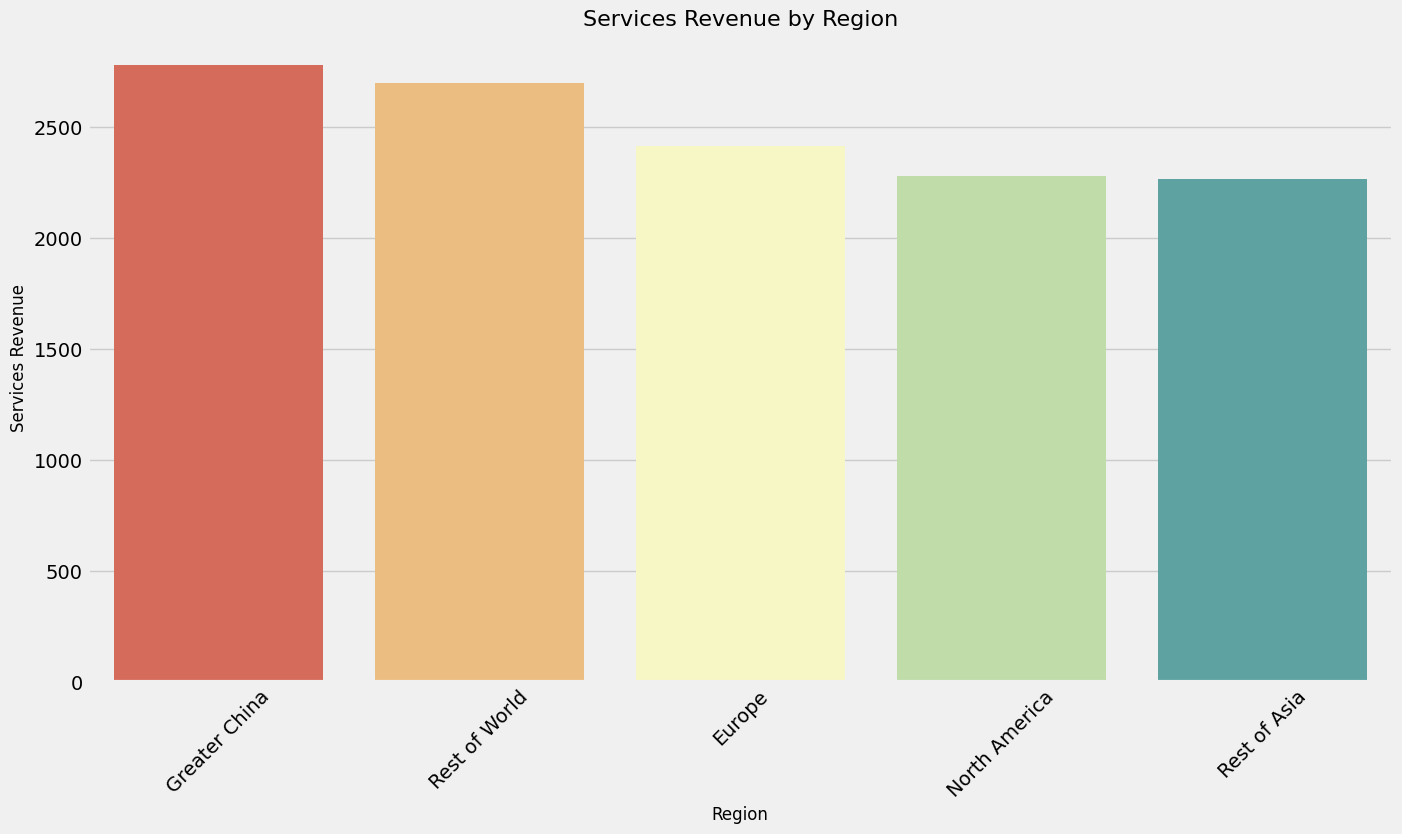

In [6]:
g1=data.groupby(['Region'])['Services_Revenue'].sum().reset_index().sort_values(by='Services_Revenue',ascending=False)

fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(data=g1,x='Region',y='Services_Revenue',palette='Spectral')
ax.set_title('Services Revenue by Region', fontsize=16)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Services Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.show()

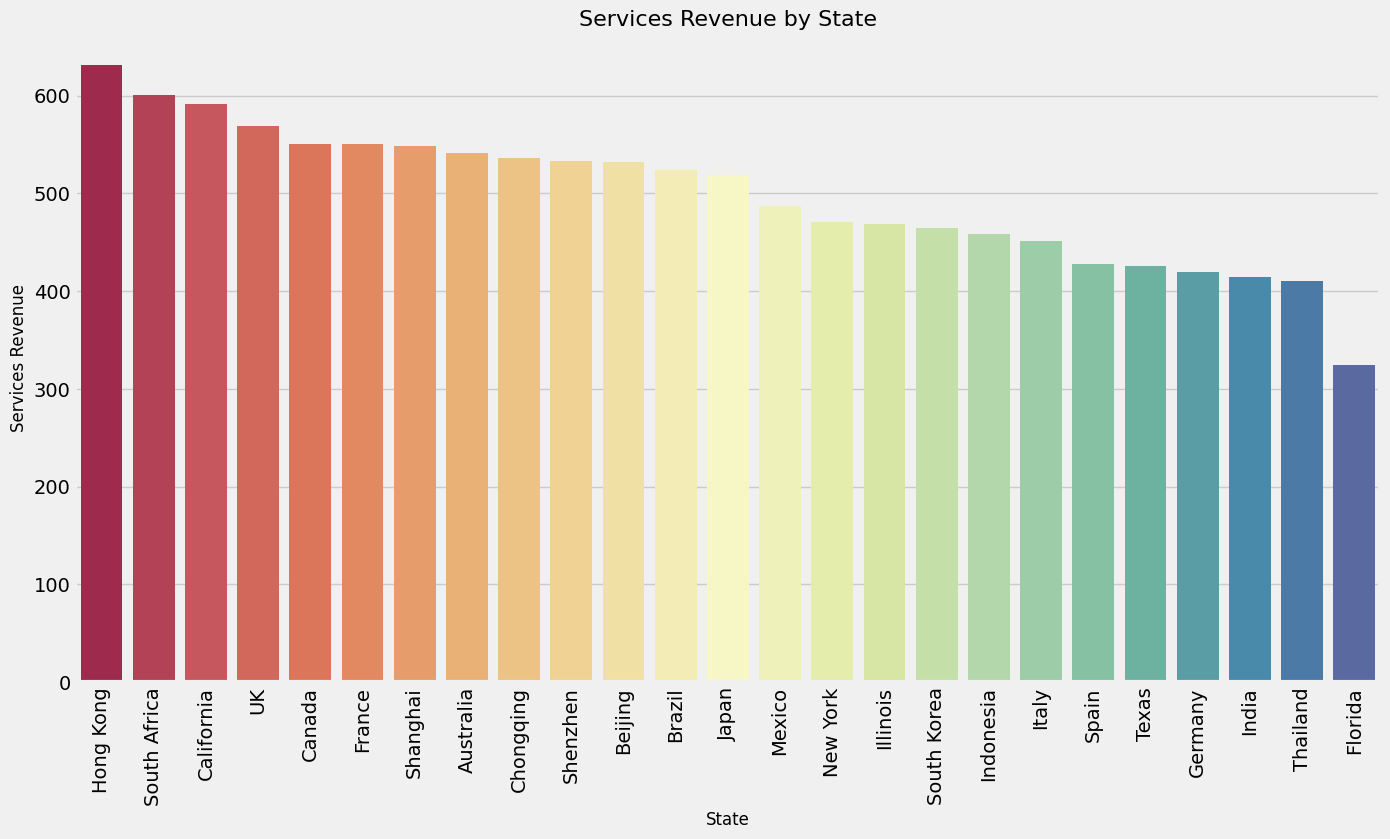

In [7]:
g2=data.groupby(['State'])['Services_Revenue'].sum().reset_index().sort_values(by='Services_Revenue',ascending=False)


fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(data=g2,x='State',y='Services_Revenue',palette='Spectral')
ax.set_title('Services Revenue by State', fontsize=16)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Services Revenue', fontsize=12)
plt.xticks(rotation=90)
plt.show()

In [8]:
def stackbar(data):
    categories = data.index
    values = data.values
    columns=data.columns
    
    fig, ax = plt.subplots(figsize=(15,6))
    cum_sum=np.zeros(len(categories))

    for i,columns in enumerate(columns):
        plot = ax.bar(categories, values[:,i],bottom=cum_sum,label=columns)
        cum_sum+=values[:,i]
    return (plot)

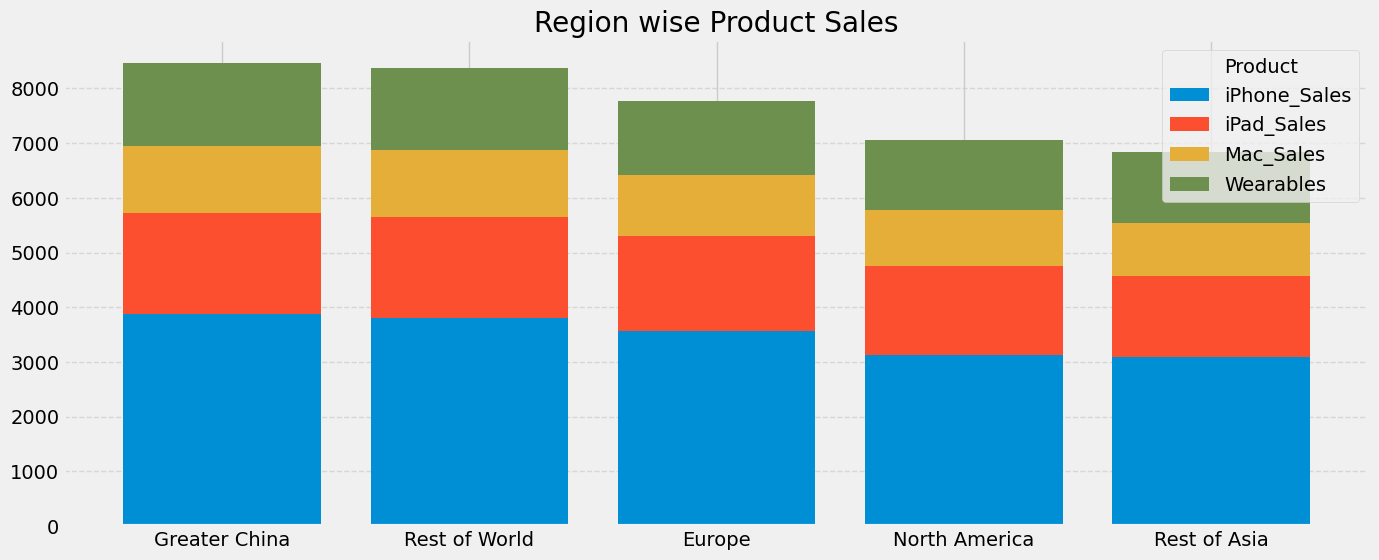

In [9]:
g3=data.groupby(['Region']).agg({'iPhone_Sales':'sum','iPad_Sales':'sum','Mac_Sales':'sum','Wearables':'sum'}).sort_values(by='iPhone_Sales',ascending=False)
stackbar(g3)
plt.title('Region wise Product Sales')
plt.legend(title='Product', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

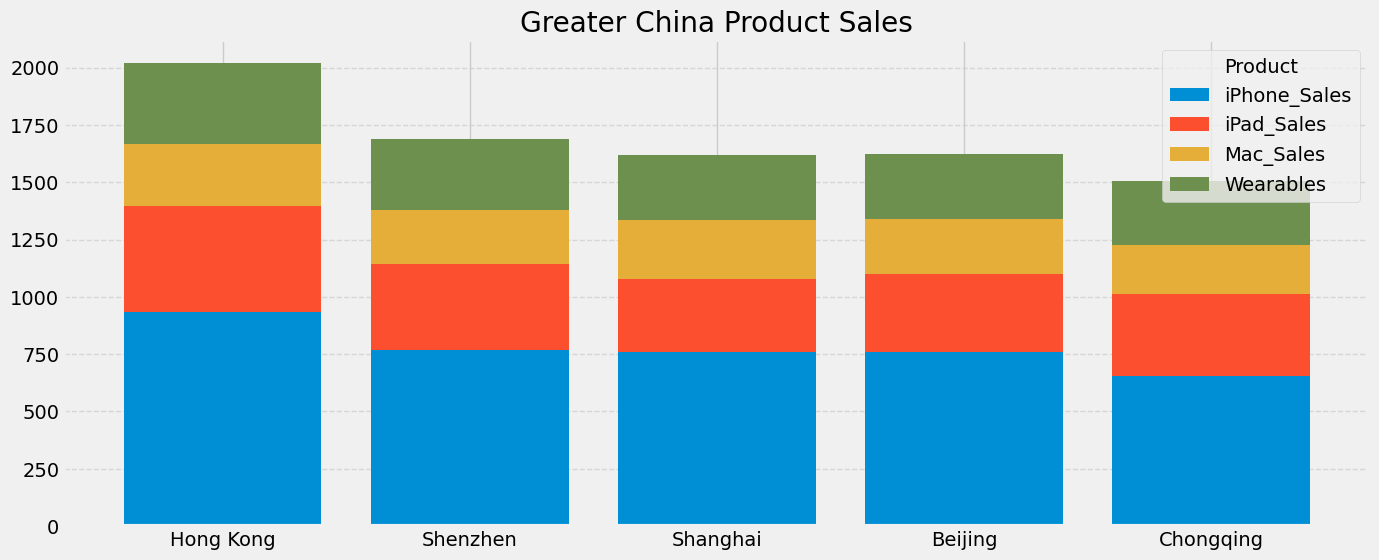

In [10]:
g4=data[data['Region']=='Greater China'].groupby(['State']).agg({'iPhone_Sales':'sum','iPad_Sales':'sum','Mac_Sales':'sum','Wearables':'sum'}).sort_values(by='iPhone_Sales',ascending=False)
stackbar(g4)
plt.title('Greater China Product Sales')
plt.legend(title='Product', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

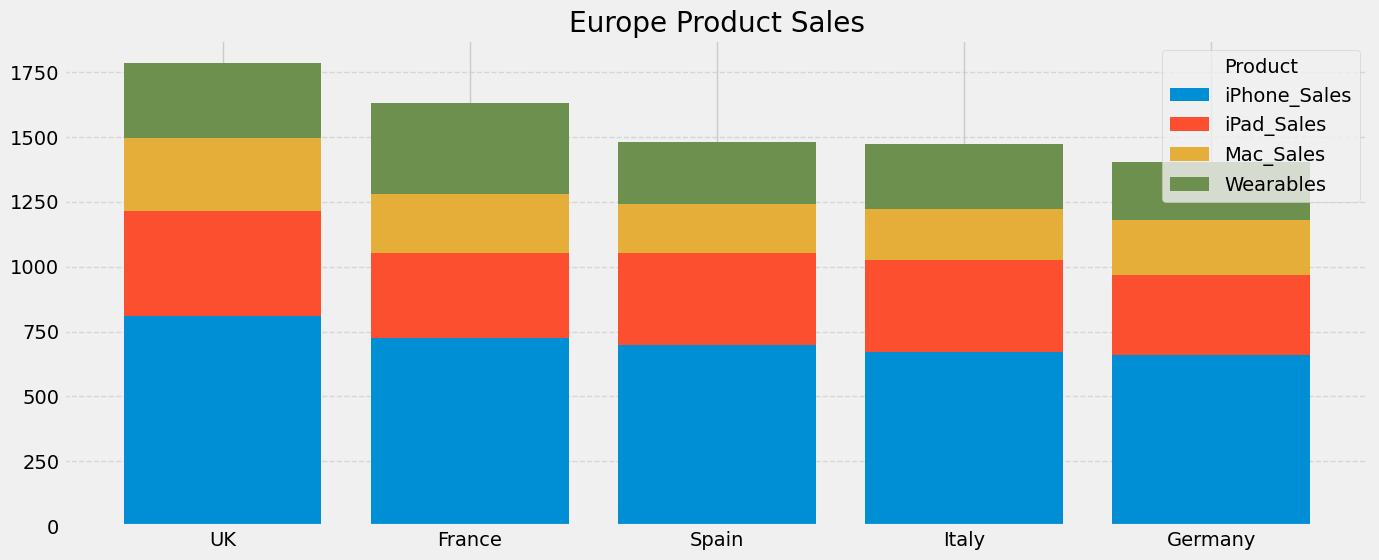

In [11]:
g5=data[data['Region']=='Europe'].groupby(['State']).agg({'iPhone_Sales':'sum','iPad_Sales':'sum','Mac_Sales':'sum','Wearables':'sum'}).sort_values(by='iPhone_Sales',ascending=False)
stackbar(g5)
plt.title('Europe Product Sales')
plt.legend(title='Product', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

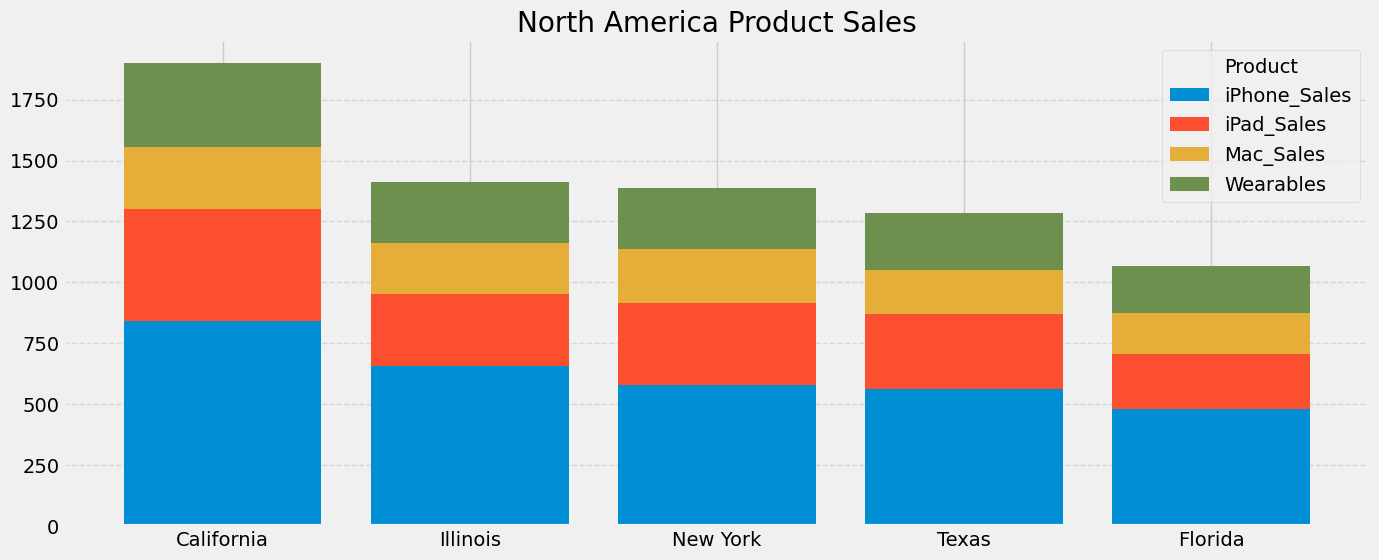

In [12]:
g6=data[data['Region']=='North America'].groupby(['State']).agg({'iPhone_Sales':'sum','iPad_Sales':'sum','Mac_Sales':'sum','Wearables':'sum'}).sort_values(by='iPhone_Sales',ascending=False)
stackbar(g6)
plt.title('North America Product Sales')
plt.legend(title='Product', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

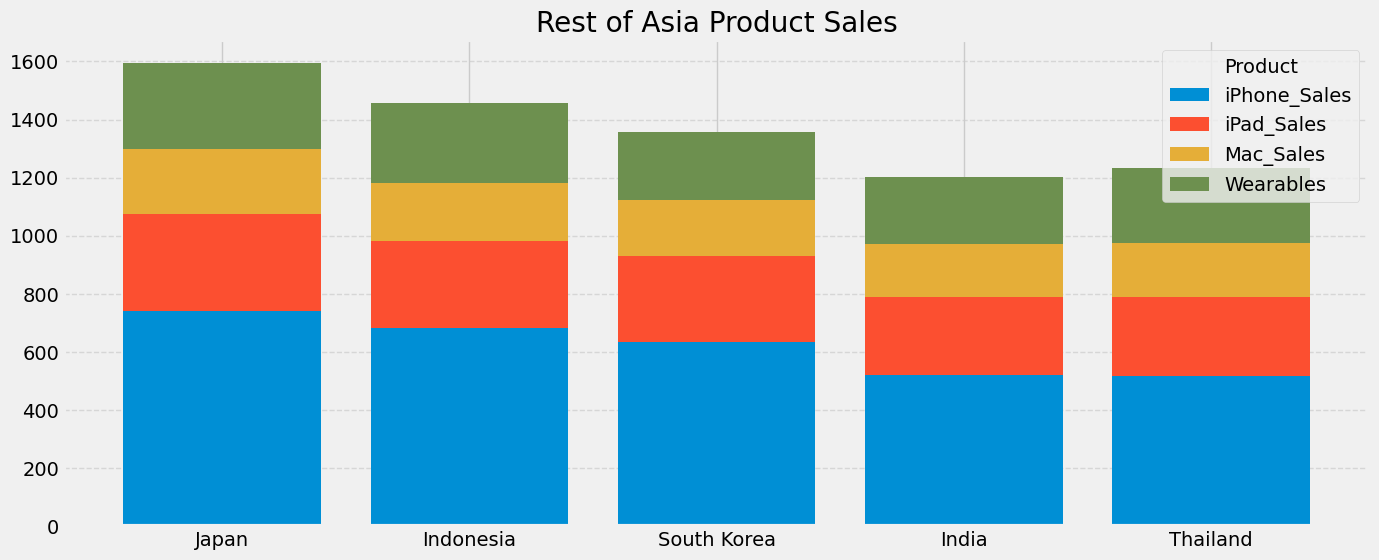

In [13]:
g7=data[data['Region']=='Rest of Asia'].groupby(['State']).agg({'iPhone_Sales':'sum','iPad_Sales':'sum','Mac_Sales':'sum','Wearables':'sum'}).sort_values(by='iPhone_Sales',ascending=False)
stackbar(g7)
plt.title('Rest of Asia Product Sales')
plt.legend(title='Product', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

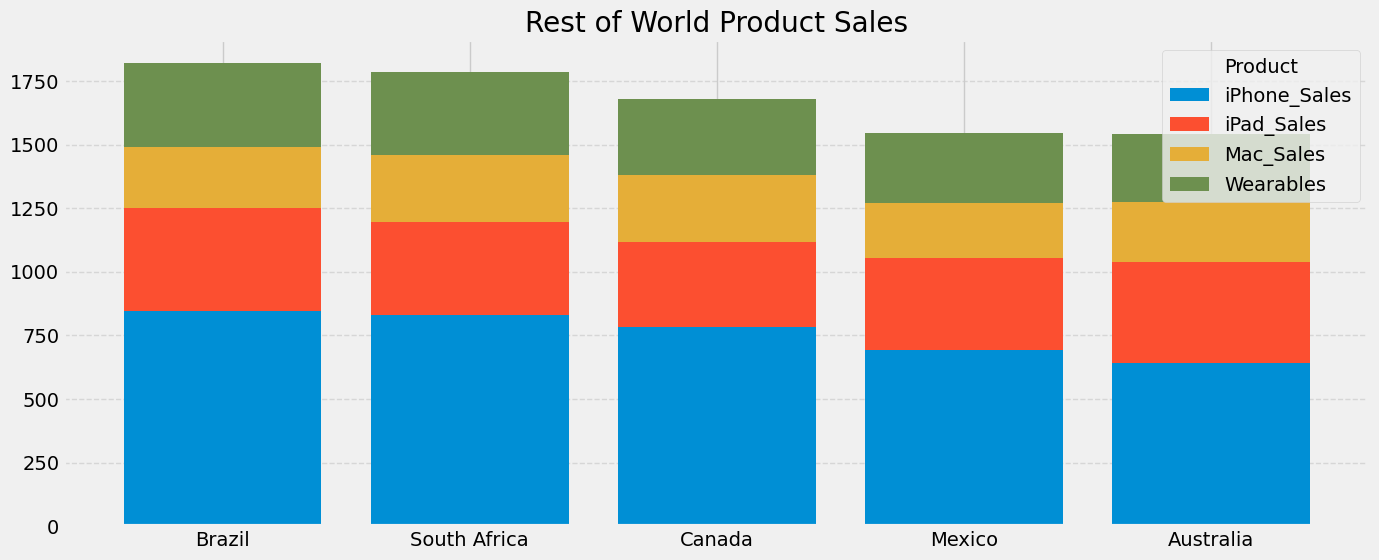

In [14]:
g8=data[data['Region']=='Rest of World'].groupby(['State']).agg({'iPhone_Sales':'sum','iPad_Sales':'sum','Mac_Sales':'sum','Wearables':'sum'}).sort_values(by='iPhone_Sales',ascending=False)
stackbar(g8)
plt.title('Rest of World Product Sales')
plt.legend(title='Product', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()